# <span>Worksheet - 9</span>
## <span>Sequential Modeling for Text Classification Using RNN
<small>

**Student Name:** Pratisha Bista  
**ID:** 2408284  
**Group:** L6CG1  

</small>

# Sequence to Sequence Model.
___
In this Notebook we will try to build and understand a Seq to Seq Model for Machine Translations.

# Download the dataset:

The following script will download the dataset and stores the file in designated folder.

Please change the folder path as per your file structure.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

base_dir = "/content/drive/MyDrive/6S012 Artificial Intelligence/Workshop/Week-9/"

try:
    files = os.listdir(base_dir)
    print(f"Contents of '{base_dir}':")

    for item in files:
        item_path = os.path.join(base_dir, item)
        if os.path.isfile(item_path):
            print(f"{item}")
        elif os.path.isdir(item_path):
            print(f"{item}")

except FileNotFoundError:
    print(f"Directory '{base_dir}' not found. Make sure Google Drive is mounted.")
except Exception as e:
    print(f"Error: {e}")

Contents of '/content/drive/MyDrive/6S012 Artificial Intelligence/Workshop/Week-9/':
cleaned_data.csv
npi.txt
raw_data.csv
Week-9.ipynb


In [3]:
import pandas as pd

base_dir = "/content/drive/MyDrive/6S012 Artificial Intelligence/Workshop/Week-9/"

root_path = os.path.join(base_dir, "raw_data.csv")

# Path to the original data file
data_path = os.path.join(base_dir, "npi.txt")

# Read the .txt file into a DataFrame
lines = pd.read_table(data_path, names=['source', 'target', 'comments'])

# Drop the 'comments' column if it exists
if 'comments' in lines.columns:
    lines = lines.drop(columns=['comments'])

# Path to save the cleaned CSV file
csv_path = os.path.join(base_dir, "cleaned_data.csv")

# Save as CSV if it doesn't already exist
if not os.path.exists(csv_path):
    lines.to_csv(csv_path, index=False, encoding='utf-8')
    print(f"CSV file saved to: {csv_path}")
else:
    print(f"CSV file already exists at: {csv_path}")

CSV file already exists at: /content/drive/MyDrive/6S012 Artificial Intelligence/Workshop/Week-9/cleaned_data.csv


In [4]:
raw_data = pd.read_csv("/content/drive/MyDrive/6S012 Artificial Intelligence/Workshop/Week-9/raw_data.csv")
raw_data.sample(6)

,source,target
566,This is a bus stop.,यो बस स्टप हो।
1773,Please call me Tom from now on.,कृपया मलाई अब देखि टम भनेर बोलाउनुहोस्।
2185,I want to be with you whenever I can.,जब म सक्छु म तिम्रो साथ हुन चाहन्छु।
1778,Things didn't turn out so well.,चीजहरू त्यति राम्ररी बाहिर आएनन्।
2400,Would it be OK if I turned the radio off?,के म रेडियो बन्द गर्न सक्छु?
581,What do they think?,तिनीहरू के सोच्छन्?


# Clean, Normalize and Prepare Target Sentences.

In [5]:
import re
import string
import os
from string import digits

def clean_text_data(df, output_path=None):
    """
    Cleans source and target text columns in a DataFrame for translation tasks.

    Parameters:
    -----------
    df : pandas.DataFrame
        A DataFrame with 'source' and 'target' columns.
        - 'source': English sentences
        - 'target': Translated Nepali sentences

    output_path : str, optional
        If provided, saves the cleaned DataFrame as CSV with 'cleaned_source' and 'cleaned_target'.
        Will not overwrite if file already exists.

    Returns:
    --------
    pandas.DataFrame
        Cleaned data with minimal changes to preserve sentence meaning.
    """

    # Lowercase both columns
    df.source = df.source.apply(lambda x: x.lower())
    df.target = df.target.apply(lambda x: x.lower())

    # Remove stray apostrophes or quotes
    df.source = df.source.apply(lambda x: re.sub(r"[\"’‘“”']", '', x))
    df.target = df.target.apply(lambda x: re.sub(r"[\"’‘“”']", '', x))

    # Remove digits only
    df.source = df.source.apply(lambda x: re.sub(r"\d+", '', x))
    df.target = df.target.apply(lambda x: re.sub(r"\d+", '', x))

    # Normalize whitespace
    df.source = df.source.apply(lambda x: re.sub(r"\s+", " ", x.strip()))
    df.target = df.target.apply(lambda x: re.sub(r"\s+", " ", x.strip()))

    # Add START_ and _END to target text
    df.target = df.target.apply(lambda x: f"START_ {x} _END")

    # Rename the cleaned columns
    df.rename(columns={"source": "cleaned_source", "target": "cleaned_target"}, inplace=True)

    # Save cleaned file (if not exists)
    if output_path:
        if not os.path.exists(output_path):
            df.to_csv(output_path, index=False, encoding='utf-8')
            print(f"Cleaned data saved to: {output_path}")
        else:
            print(f"File already exists. Skipping save: {output_path}")

    return df


In [6]:
cleaned_data_path = os.path.join(base_dir, "cleaned_data.csv")
cleaned_lines = clean_text_data(lines, cleaned_data_path)
# Check the column names
print(cleaned_lines.columns)

File already exists. Skipping save: /content/drive/MyDrive/6S012 Artificial Intelligence/Workshop/Week-9/cleaned_data.csv
Index(['cleaned_source', 'cleaned_target'], dtype='object')


### For sanity - ReLoad the Cleaned Dataset.

For consistency, we reload the dataset from the saved CSV. The earlier extraction and saving steps will not be rerun moving forward

In [7]:
import pandas as pd
cleaned_data = pd.read_csv("/content/drive/MyDrive/6S012 Artificial Intelligence/Workshop/Week-9/cleaned_data.csv")

In [8]:
cleaned_data.sample(6)

,cleaned_source,cleaned_target
1850,its getting darker outside now.,START_ बाहिर अँध्यारो हुँदैछ। _END
725,i need to rent a car.,START_ मलाई एउटा कार भाडामा लिनु पर्ने छ। _END
356,i drink to relax.,START_ म आराम गर्न पिउँछु। _END
1941,you must respect senior citizens.,START_ ज्येष्ठ नागरिकलाई सम्मान गर्नुपर्छ। _END
562,the house is empty.,START_ घर खाली छ । _END
732,id like to be alone.,START_ म एक्लै बस्न चाहन्छु। _END


### Vocabulary Extractions:

We put all the words from source[English] to a list called source vocabulary.

We put all the words from target[Nepali] to a list called target vocabulary.

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from tensorflow.keras.preprocessing.sequence import pad_sequences
from collections import Counter

In [10]:
all_source_words = set()
for source in cleaned_data.cleaned_source:
    for word in source.split():
        all_source_words.add(word)

all_target_words = set()
for target in cleaned_data.cleaned_target:
    for word in target.split():
        all_target_words.add(word)

source_words = sorted(list(all_source_words))
target_words = sorted(list(all_target_words))
print(len(target_words))

3269


### Sentence Length Calculation:

Finding longest sentence both in Source and Target.



In [11]:
#Find maximum sentence length in  the source and target data
source_length_list=[]
for l in cleaned_data.cleaned_source:
    source_length_list.append(len(l.split(' ')))
max_source_length= max(source_length_list)
print(" Max length of the source sentence",max_source_length)
target_length_list=[]
for l in cleaned_data.cleaned_target:
    target_length_list.append(len(l.split(' ')))
max_target_length= max(target_length_list)
print(" Max length of the target sentence",max_target_length)

 Max length of the source sentence 25
 Max length of the target sentence 22


### Word - to - Index and Index - to - Word Mapping

Creating a Look Up table.
  1.   We create a dicitionary word2indx both for source and target.
  2.   We will also Creata reverse dicitionary indx2word for both source and target.



In [12]:
# Define special tokens
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

# Create word-to-index dictionaries
source_word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1} | dict([(word, i+2) for i, word in enumerate(source_words)])
target_word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1} | dict([(word, i+2) for i, word in enumerate(target_words)])

# Create index-to-word dictionaries
source_idx2word = {i: word for word, i in source_word2idx.items()}
target_idx2word = {i: word for word, i in target_word2idx.items()}

# Check if the dictionaries have been properly created
print(source_word2idx)
print(len(target_word2idx))
print(source_idx2word)
print(len(target_idx2word))

{'<PAD>': 0, '<UNK>': 1, ',': 2, '.': 3, ':': 4, ':.': 5, '?': 6, 'a': 7, 'able': 8, 'aboard.': 9, 'about': 10, 'about?': 11, 'above': 12, 'abroad': 13, 'abroad.': 14, 'abused': 15, 'accept': 16, 'accept.': 17, 'accepted': 18, 'accident.': 19, 'accountant?': 20, 'accurate': 21, 'accurately': 22, 'across': 23, 'act': 24, 'active.': 25, 'actor?': 26, 'actually': 27, 'actually,': 28, 'add?': 29, 'addict.': 30, 'address.': 31, 'admit': 32, 'admitted': 33, 'advance': 34, 'advance.': 35, 'adventures': 36, 'advice,': 37, 'advice.': 38, 'afraid': 39, 'after': 40, 'afternoon.': 41, 'afternoon?': 42, 'again': 43, 'again,': 44, 'again.': 45, 'again?': 46, 'age.': 47, 'aggressive.': 48, 'ago.': 49, 'agree': 50, 'agreed': 51, 'ahead': 52, 'airport': 53, 'alcohol?': 54, 'alice': 55, 'all': 56, 'all.': 57, 'all?': 58, 'allergic': 59, 'allergies.': 60, 'allowed': 61, 'almost': 62, 'alone': 63, 'alone!': 64, 'alone.': 65, 'alone?': 66, 'along': 67, 'already': 68, 'also': 69, 'alternative.': 70, 'always

### Shuffle and Split:

In [13]:
#Shuffle the data
lines = shuffle(cleaned_data)
# Train - Test Split
X, y = cleaned_data.cleaned_source, cleaned_data.cleaned_target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1)
X_train.shape, X_test.shape

((2420,), (269,))

In [14]:
# Input tokens for encoder
num_encoder_tokens=len(source_word2idx)
# Input tokens for decoder zero padded
num_decoder_tokens=len(target_idx2word)
print(num_decoder_tokens)

3271


## Generate in Batch:

To manage our memory we will create and input data pipeline in batches.

In [15]:
def generate_batch(X, y, batch_size=128):
    while True:
        for j in range(0, len(X), batch_size):
            batch_X = X[j:j + batch_size]
            batch_y = y[j:j + batch_size]

            encoder_input_data = np.zeros((len(batch_X), max_source_length), dtype='float32')
            decoder_input_data = np.zeros((len(batch_X), max_target_length), dtype='float32')
            decoder_target_data = np.zeros((len(batch_X), max_target_length, num_decoder_tokens), dtype='float32')

            for i, (input_text, target_text) in enumerate(zip(batch_X, batch_y)):
                input_seq = [source_word2idx.get(word, source_word2idx[UNK_TOKEN]) for word in input_text.split()]
                target_seq = [target_word2idx.get(word, target_word2idx[UNK_TOKEN]) for word in target_text.split()]

                encoder_input_data[i] = pad_sequences([input_seq], maxlen=max_source_length, padding='post')[0]
                decoder_input_data[i] = pad_sequences([target_seq], maxlen=max_target_length, padding='post')[0]

                for t in range(1, len(target_seq)):
                    decoder_target_data[i, t - 1, target_seq[t]] = 1.

            # Yield as expected structure: ((inputs), targets)
            yield ((encoder_input_data, decoder_input_data), decoder_target_data)

In [16]:
def create_tf_dataset(X, y, batch_size=128):
    output_signature = (
        (tf.TensorSpec(shape=(None, max_source_length), dtype=tf.float32),  # encoder_input_data
         tf.TensorSpec(shape=(None, max_target_length), dtype=tf.float32)),  # decoder_input_data
        tf.TensorSpec(shape=(None, max_target_length, num_decoder_tokens), dtype=tf.float32)  # decoder_target_data
    )
    return tf.data.Dataset.from_generator(
        lambda: generate_batch(X, y, batch_size),  # Lambda to call the generator function
        output_signature=output_signature  # Defining the output signature for the dataset
    )


# Model Building:

1. encoder inputs: The 2D array will be of shape (batch_size, max source sentence length). For a batch_size of 128 and a max source sentence length of 47, the shape of encoder_input will be (128,47)

2. decoder inputs: The 2D array will be of shape (batch_size, max target sentence length). For a batch_size of 128 and a max target sentence length of 55, the shape of decoder inputs will be (128,55)

3. decoder outputs: The 3D array will be of shape (batch_size, max target sentence length, number of unique words in target sentences). For a batch_size of 128 and a max target sentence length of 55, the shape of decoder output will be (128,55, 27200).

## Encoder Architecture:
Encoder encodes the input sentence.
1. It takes the input source tokens from input layer.
2. Embedding layer then translates sparse vectors into a dense lower dimesional space preserving teh semantic realtionships.
3. Create the LSTM layer and only set return_state to True, because we want hidden state and cell state, as an input to decoder.

In [17]:
train_samples = len(X_train)
val_samples = len(X_test)
batch_size = 128
epochs = 50
latent_dim=256

In [18]:
def define_encoder(input_shape, num_encoder_tokens, latent_dim):
    """
    Defines the encoder architecture for a sequence-to-sequence model.

    The encoder processes input sequences through an embedding layer and LSTM,
    returning the final states that capture the encoded information.
    Parameters:
    -----------
    input_shape : tuple
        Shape of the input tensor (max_sequence_length,) for variable-length sequences
    num_encoder_tokens : int
        Size of the source vocabulary (including special tokens)
    latent_dim : int
        Dimensionality of the embedding and LSTM layers
    Returns:
    --------
    tuple: (encoder_inputs, encoder_states)
        encoder_inputs : keras.Input
            Input layer for the encoder
        encoder_states : list
            Final states [hidden_state, cell_state] from the LSTM
    """
    encoder_inputs = Input(shape=input_shape, name='encoder_inputs')
    enc_emb = Embedding(num_encoder_tokens, latent_dim, mask_zero=True, name='encoder_embedding')(encoder_inputs)
    encoder_lstm = LSTM(latent_dim, return_state=True, name='encoder_lstm')
    encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)
    encoder_states = [state_h, state_c]

    return encoder_inputs, encoder_states

## Decoder Architecture.

1. Decoder uses hidden state and cell state from encoder and from embedding layer as an input.

2. Decoder returns output sentence and also hidden and cell states.

3. The final layer in decoder is linear layer(dense) with softmax activation function used for predictions.


In [19]:
def define_decoder(latent_dim, num_decoder_tokens, encoder_states, max_target_length):
    """
    Defines the decoder architecture for a sequence-to-sequence model.

    The decoder processes target sequences through an embedding layer and LSTM,
    using the encoder states as initial state, and outputs probability distributions
    over the target vocabulary via a dense softmax layer.

    Parameters:
    -----------
    latent_dim : int
        Dimensionality of the embedding and LSTM layers (must match encoder)
    num_decoder_tokens : int
        Size of the target vocabulary (including special tokens)
    encoder_states : list
        Final states [hidden_state, cell_state] from the encoder LSTM
    max_target_length : int
        Maximum length of target sequences (for shape reference)

    Returns:
    --------
    tuple: (decoder_inputs, decoder_outputs)
        decoder_inputs : keras.Input
            Input layer for the decoder (teacher forcing inputs)
        decoder_outputs : keras.Layer
            Output tensor containing sequence of vocabulary probabilities
    """
    decoder_inputs = Input(shape=(None,), name='decoder_inputs')
    dec_emb_layer = Embedding(num_decoder_tokens, latent_dim, mask_zero=True, name='decoder_embedding')
    dec_emb = dec_emb_layer(decoder_inputs)

    decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True, name='decoder_lstm')
    decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)

    decoder_dense = Dense(num_decoder_tokens, activation='softmax', name='decoder_dense')
    decoder_outputs = decoder_dense(decoder_outputs)

    return decoder_inputs, decoder_outputs, dec_emb_layer, decoder_lstm, decoder_dense

### Building Seq - to - Seq Model:
This function creates a complete model that:

1. Encodes input sequences into context vectors
2. Decodes the context vectors into target sequences
3. Outputs probability distributions over the target vocabulary

In [20]:
def build_seq2seq_model(input_shape, num_encoder_tokens, num_decoder_tokens, latent_dim, max_target_length):
    """
    Constructs an end-to-end sequence-to-sequence model combining encoder and decoder.
    Parameters:
    -----------
    input_shape : tuple
        Shape of the input sequences (max_sequence_length,)
    num_encoder_tokens : int
        Size of the source vocabulary (including special tokens)
    num_decoder_tokens : int
        Size of the target vocabulary (including special tokens)
    latent_dim : int
        Dimensionality of the embedding and LSTM layers
    max_target_length : int
        Maximum length of target sequences (for reference)

    Returns:
    --------
    keras.Model
        A compiled seq2seq model with encoder and decoder components
    """
    encoder_inputs, encoder_states = define_encoder(input_shape, num_encoder_tokens, latent_dim)
    decoder_inputs, decoder_outputs, dec_emb_layer, decoder_lstm, decoder_dense = define_decoder(latent_dim, num_decoder_tokens, encoder_states, max_target_length)

    model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
    return model, encoder_inputs, decoder_inputs, encoder_states, dec_emb_layer, decoder_lstm, decoder_dense

In [21]:
# Create dataset
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense

train_dataset = create_tf_dataset(X_train, y_train, batch_size=batch_size)
val_dataset = create_tf_dataset(X_test, y_test, batch_size=batch_size)

# Test the first batch
for batch in train_dataset.take(1):
    print(f"Input data shape: {batch[0][0].shape}, {batch[0][1].shape}")  # encoder_input_data, decoder_input_data
    print(f"Target data shape: {batch[1].shape}")  # decoder_target_data

Input data shape: (128, 25), (128, 22)
Target data shape: (128, 22, 3271)


In [22]:
# Prepare the dataset for training
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)  # Optimizing for performance
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

# Build and compile the model
input_shape = (None,)  # Variable-length input sequence (e.g., (None,))
latent_dim = 256  # Latent dimension for LSTM
model, encoder_inputs, decoder_inputs, encoder_states, dec_emb_layer, decoder_lstm, decoder_dense = build_seq2seq_model(
    input_shape=(max_source_length,),
    num_encoder_tokens=num_encoder_tokens,
    num_decoder_tokens=num_decoder_tokens,
    latent_dim=latent_dim,
    max_target_length=max_target_length
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 25)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 25, 256)   │    686,848 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 25)        │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, None, 256) │    837,376 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 256),     │    525,312 │ encoder_embeddin… │
│                     │ (None, 256),      │            │ not_equal[0][0]   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, None,     │    525,312 │ decoder_embeddin… │
│                     │ 256), (None,      │            │ encoder_lstm[0][… │
│                     │ 256), (None,      │            │ encoder_lstm[0][… │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, None,      │    840,647 │ decoder_lstm[0][… │
│ (Dense)             │ 3271)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,415,495 (13.03 MB)

 Trainable params: 3,415,495 (13.03 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Define callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, min_delta=0.001, restore_best_weights=True, verbose=1),

    # Save the model with the best validation accuracy
    ModelCheckpoint('best_seq2seq_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# 2. Compile the model
model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Training parameters
train_samples = len(X_train)
val_samples = len(X_test)

steps_per_epoch = train_samples // batch_size
validation_steps = val_samples // batch_size

# 4. Train the model with callbacks
model.fit(
    train_dataset,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    validation_data=val_dataset,
    validation_steps=validation_steps,
    callbacks=callbacks
)

# 5. Save final model (optional, in case best wasn't triggered)
model.save('final_seq2seq_model.h5')

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1104 - loss: 6.9723
Epoch 1: val_accuracy improved from None to 0.13905, saving model to best_seq2seq_model.h5



Epoch 1: finished saving model to best_seq2seq_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.1298 - loss: 6.9296 - val_accuracy: 0.1391 - val_loss: 6.6089
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1368 - loss: 6.0708
Epoch 2: val_accuracy did not improve from 0.13905
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1370 - loss: 5.7643 - val_accuracy: 0.1391 - val_loss: 5.3857
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1441 - loss: 5.3180
Epoch 3: val_accuracy improved from 0.13905 to 0.16839, saving model to best_seq2seq_model.h5



Epoch 3: finished saving model to best_seq2seq_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.1519 - loss: 5.2551 - val_accuracy: 0.1684 - val_loss: 5.1243
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1651 - loss: 5.0722
Epoch 4: val_accuracy did not improve from 0.16839
18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.1625 - loss: 5.0560 - val_accuracy: 0.1684 - val_loss: 5.0043
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1661 - loss: 4.9499
Epoch 5: val_accuracy did not improve from 0.16839
18/18 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.1631 - loss: 4.9509 - val_accuracy: 0.1684 - val_loss: 4.9336
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1654 - loss: 4.8785
Epoch 6: val_accuracy improved from 0.16839 to 0.17110, saving model to best_seq2seq_model.h5



Epoch 6: finished saving model to best_seq2seq_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.1644 - loss: 4.8846 - val_accuracy: 0.1711 - val_loss: 4.9106
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1654 - loss: 4.8409
Epoch 7: val_accuracy improved from 0.17110 to 0.17273, saving model to best_seq2seq_model.h5



Epoch 7: finished saving model to best_seq2seq_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1657 - loss: 4.8336 - val_accuracy: 0.1727 - val_loss: 4.8661
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1660 - loss: 4.8128
Epoch 8: val_accuracy did not improve from 0.17273
18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.1661 - loss: 4.7989 - val_accuracy: 0.1711 - val_loss: 4.8531
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1682 - loss: 4.7860
Epoch 9: val_accuracy improved from 0.17273 to 0.17328, saving model to best_seq2seq_model.h5


...


Epoch 42: finished saving model to best_seq2seq_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.2061 - loss: 3.9839 - val_accuracy: 0.2080 - val_loss: 4.4789
Epoch 43/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2143 - loss: 3.9245
Epoch 43: val_accuracy improved from 0.20804 to 0.21238, saving model to best_seq2seq_model.h5



Epoch 43: finished saving model to best_seq2seq_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.2106 - loss: 3.9463 - val_accuracy: 0.2124 - val_loss: 4.4568
Epoch 44/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2141 - loss: 3.9146
Epoch 44: val_accuracy did not improve from 0.21238
18/18 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.2128 - loss: 3.9214 - val_accuracy: 0.2097 - val_loss: 4.4795
Epoch 45/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2124 - loss: 3.9112
Epoch 45: val_accuracy improved from 0.21238 to 0.22053, saving model to best_seq2seq_model.h5



Epoch 45: finished saving model to best_seq2seq_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.2138 - loss: 3.9013 - val_accuracy: 0.2205 - val_loss: 4.4589
Epoch 46/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2144 - loss: 3.8887
Epoch 46: val_accuracy did not improve from 0.22053
18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.2169 - loss: 3.8718 - val_accuracy: 0.2184 - val_loss: 4.4476
Epoch 47/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2163 - loss: 3.8694
Epoch 47: val_accuracy improved from 0.22053 to 0.22216, saving model to best_seq2seq_model.h5



Epoch 47: finished saving model to best_seq2seq_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.2192 - loss: 3.8473 - val_accuracy: 0.2222 - val_loss: 4.4429
Epoch 48/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2174 - loss: 3.8494
Epoch 48: val_accuracy did not improve from 0.22216
18/18 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.2207 - loss: 3.8239 - val_accuracy: 0.2211 - val_loss: 4.4172
Epoch 49/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2215 - loss: 3.8055
Epoch 49: val_accuracy did not improve from 0.22216
18/18 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.2224 - loss: 3.7917 - val_accuracy: 0.2200 - val_loss: 4.4042
Epoch 50/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2229 - loss: 3.7953
Epoch 50: val_accuracy improved from 0.22216 to 0.22325, saving model to best_seq2seq_model.h5



Epoch 50: finished saving model to best_seq2seq_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.2245 - loss: 3.7758 - val_accuracy: 0.2232 - val_loss: 4.3897
Restoring model weights from the end of the best epoch: 50.



Epoch 1: val_accuracy did not improve from 0.22325

Epoch 2: val_accuracy improved from 0.22325 to 0.22325, saving model to best_seq2seq_model.h5



Epoch 2: finished saving model to best_seq2seq_model.h5

Epoch 3: val_accuracy improved from 0.22325 to 0.22596, saving model to best_seq2seq_model.h5



Epoch 3: finished saving model to best_seq2seq_model.h5

Epoch 4: val_accuracy improved from 0.22596 to 0.22814, saving model to best_seq2seq_model.h5



Epoch 4: finished saving model to best_seq2seq_model.h5

Epoch 5: val_accuracy did not improve from 0.22814

Epoch 6: val_accuracy improved from 0.22814 to 0.23357, saving model to best_seq2seq_model.h5



Epoch 6: finished saving model to best_seq2seq_model.h5

Epoch 7: val_accuracy did not improve from 0.23357

Epoch 8: val_accuracy improved from 0.23357 to 0.23466, saving model to best_seq2seq_model.h5


...


Epoch 34: finished saving model to best_seq2seq_model.h5

Epoch 35: val_accuracy did not improve from 0.26725

Epoch 36: val_accuracy did not improve from 0.26725

Epoch 37: val_accuracy did not improve from 0.26725

Epoch 38: val_accuracy improved from 0.26725 to 0.27159, saving model to best_seq2seq_model.h5



Epoch 38: finished saving model to best_seq2seq_model.h5

Epoch 39: val_accuracy improved from 0.27159 to 0.27539, saving model to best_seq2seq_model.h5



Epoch 39: finished saving model to best_seq2seq_model.h5

Epoch 40: val_accuracy did not improve from 0.27539

Epoch 41: val_accuracy did not improve from 0.27539

Epoch 42: val_accuracy did not improve from 0.27539

Epoch 43: val_accuracy did not improve from 0.27539

Epoch 44: val_accuracy did not improve from 0.27539

Epoch 45: val_accuracy did not improve from 0.27539

Epoch 46: val_accuracy did not improve from 0.27539

Epoch 47: val_accuracy did not improve from 0.27539

Epoch 48: val_accuracy improved from 0.27539 to 0.27648, saving model to best_seq2seq_model.h5



Epoch 48: finished saving model to best_seq2seq_model.h5

Epoch 49: val_accuracy did not improve from 0.27648

Epoch 50: val_accuracy improved from 0.27648 to 0.27702, saving model to best_seq2seq_model.h5



Epoch 50: finished saving model to best_seq2seq_model.h5
Restoring model weights from the end of the best epoch: 46.


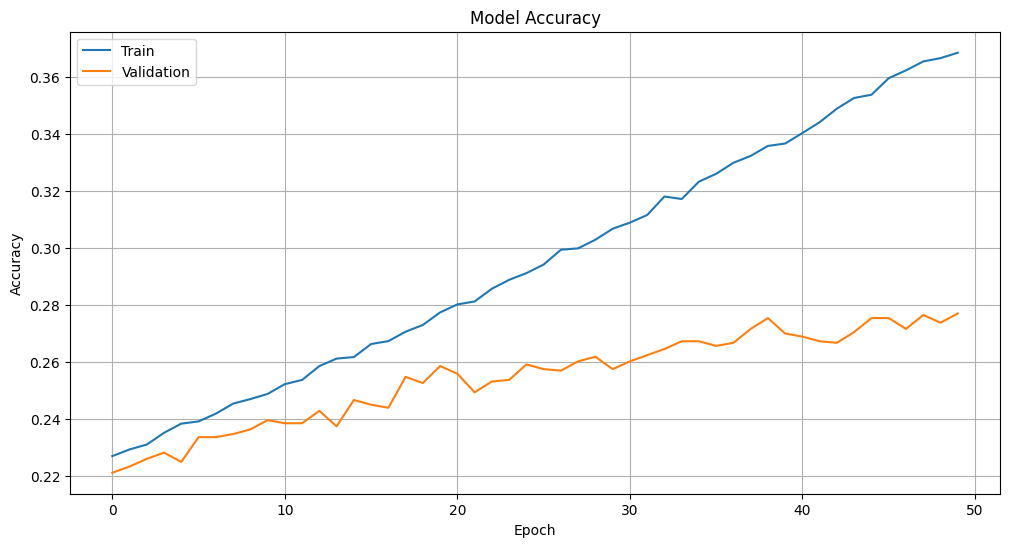

In [24]:
history = model.fit(
    train_dataset,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    validation_data=val_dataset,
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=0
)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()


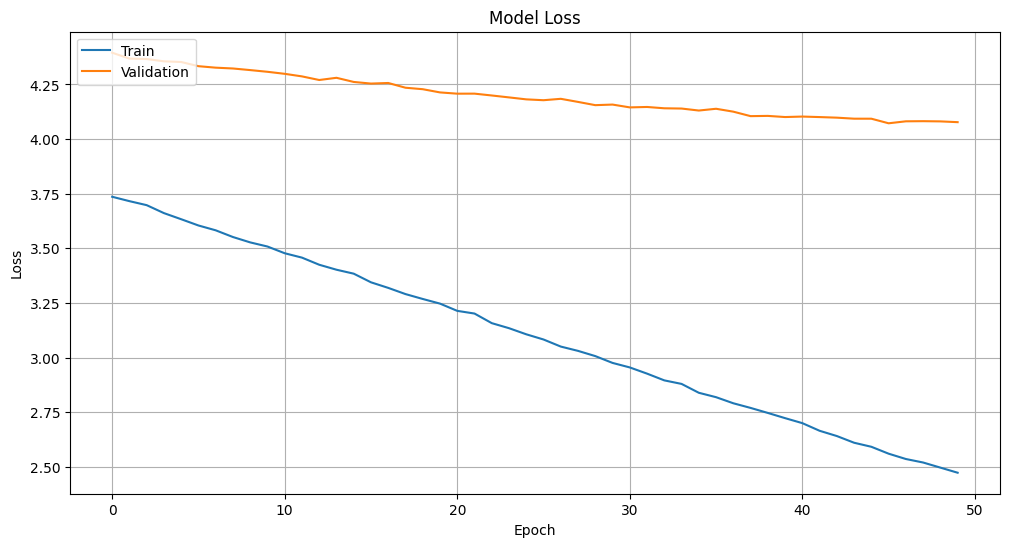

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()


## Make Inferences:

Steps in Inferences:

1. Encode the input sequences into hidden state and cell state of the LSTM
2. The decoder will predict one sequence at a time. The first input to the decoder will be hidden state and cell state of the encoder and the START_ tag
3. The output of the decoder will be fed as an input to the decoder for the next time step as shown in the diagram below.
4. At each time step, decoder outputs one-hot encoded vector to which we apply np.argmax and convert the vector to word from the dictionary that stores index to word
5. Keep appending the target words generated at each time step
Repeat the steps till we hit the _END tag or the word limit
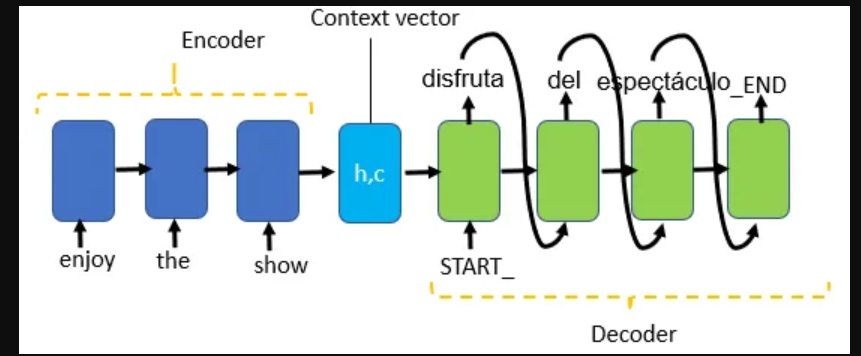

In [26]:
# Encoder model (same as in training)
encoder_model = Model(encoder_inputs, encoder_states)

# Decoder setup for inference
# These inputs will hold the LSTM states for each timestep
decoder_state_input_h = Input(shape=(latent_dim,), name='decoder_input_h')
decoder_state_input_c = Input(shape=(latent_dim,), name='decoder_input_c')
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

# Embedding layer reused from training
dec_emb2 = dec_emb_layer(decoder_inputs)

# Reuse the LSTM layer and pass in the previous states
decoder_outputs2, state_h2, state_c2 = decoder_lstm(
    dec_emb2, initial_state=decoder_states_inputs
)
decoder_states2 = [state_h2, state_c2]

# Reuse the dense softmax layer
decoder_outputs2 = decoder_dense(decoder_outputs2)

# Final inference decoder model
decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs2] + decoder_states2
)

### Function for Quick Predictions.

In [27]:
def decode_sequence(input_seq):
    # Encode the input as state vectors.
    states_value = encoder_model.predict(input_seq)
    # Generate empty target sequence of length 1.
    target_seq = np.zeros((1,1))
    # Populate the first character of
    #target sequence with the start character.
    target_seq[0, 0] = target_word2idx['START_']
# Sampling loop for a batch of sequences
    # (to simplify, here we assume a batch of size 1).
    stop_condition = False
    decoded_sentence = ''
    while not stop_condition:
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value)
# Sample a token
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_word =target_idx2word[sampled_token_index]
        decoded_sentence += ' '+ sampled_word
# Exit condition: either hit max length
        # or find stop character.
        if (sampled_word == '_END' or
           len(decoded_sentence) > 50):
            stop_condition = True
# Update the target sequence (of length 1).
        target_seq = np.zeros((1,1))
        target_seq[0, 0] = sampled_token_index
# Update states
        states_value = [h, c]
    return decoded_sentence

In [28]:
train_gen = generate_batch(X_train, y_train, batch_size = 1)
k=-1

In [29]:
k+=1
(input_seq, actual_output), _ = next(train_gen)
decoded_sentence = decode_sequence(input_seq)
print('Input Source sentence:', X_train[k:k+1].values[0])
print('Actual Target Translation:', y_train[k:k+1].values[0][6:-4])
print('Predicted Target Translation:', decoded_sentence[:-4])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Input Source sentence: why arent they here?
Actual Target Translation:  तिनीहरू यहाँ किन छैनन्? 
Predicted Target Translation:  तपाईंले किन किन ? 
